# EV02 Battery Health Diagnostic Report
## Electrified Excavator — Battery Pack Analysis

---

**Vehicle:** EV02  
**Analysis Window:** 2026-01-22 → 2026-05-14  
**Data:** Silver (1 Hz telemetry) + Cell gold features merged into master dataset  
**Purpose:** Identify battery health patterns, module-level anomalies, and degraded cells

---

### What this notebook covers
1. Operating profile (active hours, SOC range, current distribution)
2. Battery pack health (cell spread, pack voltage std, temperature range)
3. Module-by-module comparison (thermal dominance, voltage ranking)
4. Which module runs hottest and why
5. Degraded cell analysis (worst cell identity, module breakdown)
6. When does imbalance get worse? (SOC, current, operating regime)
7. Worst operating condition (low SOC + heavy load combination)
8. Trip-level analysis (most stressed sessions)
9. Executive summary dashboard

## Setup

**What this does:** Imports libraries and configures plotting style.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.titlesize': 15,
    'figure.titleweight': 'bold',
})

import os
# Ensure working directory is the project root regardless of where Jupyter starts
_nb_dir = Path('__file__').parent if '__file__' in dir() else Path.cwd()
_project_root = Path('/Users/rhythmparashar/Desktop/ev-predictive-analytics')
if _project_root.exists():
    os.chdir(_project_root)

MASTER = Path('data/analysis/master')
VEHICLE_ID = 'EV02'
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']
MODULE_COLORS = {1: '#E53935', 2: '#1E88E5', 3: '#43A047', 4: '#FB8C00', 5: '#8E24AA'}

print('Setup complete. Ready to load data.')

Setup complete. Ready to load data.


---
## Section 1 — Load Data

**What this does:** Loads all master dataset partitions into a single dataframe.  
**What to look for:** Total rows, date range, and that all 5 modules are present.

In [2]:
dfs = []
for p in sorted(MASTER.glob(f'dt=*/vehicle_id={VEHICLE_ID}.parquet')):
    dfs.append(pd.read_parquet(p))

df = pd.concat(dfs, ignore_index=True)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['date'] = df['timestamp'].dt.date.astype(str)

# Remove flatline artifact rows (cell_quality_flag bit 32)
df_clean = df[(df['cell_quality_flag'] & 32) == 0].copy()

# Derive hottest and lowest voltage module numbers
df_clean['hottest_module'] = pd.to_numeric(
    df_clean['hottest_module_id'].astype(str).str.extract(r'(\d+)')[0], errors='coerce'
)
mod_mean_cols = [f'module_{i}_voltage_mean' for i in range(1, 6)]
df_clean['lowest_voltage_module'] = df_clean[mod_mean_cols].idxmin(axis=1).str.extract(r'(\d+)').astype(float)

print(f'Total rows loaded:        {len(df):,}')
print(f'Clean rows (no flatline): {len(df_clean):,}')
print(f'Flatline rows removed:    {len(df) - len(df_clean):,}')
print(f'Date range:               {df_clean["date"].min()} → {df_clean["date"].max()}')
print(f'Unique dates:             {df_clean["date"].nunique()}')
print(f'Unique trips:             {df_clean["trip_id"].nunique():,}')
print(f'Columns:                  {len(df_clean.columns)}')

Total rows loaded:        937,458
Clean rows (no flatline): 31,564
Flatline rows removed:    905,894
Date range:               2026-01-22 → 2026-05-14
Unique dates:             69
Unique trips:             131
Columns:                  71


---
## Section 2 — Operating Profile

**What this does:** Builds a daily activity profile.
**What to look for:** Active hours per day, SOC working range, current distribution.

In [3]:
daily = df_clean.groupby('date').agg(
    total_rows=('timestamp', 'count'),
    active_rows=('abs_current_a', lambda x: (x > 10).sum()),
    soc_max=('soc_pct', 'max'),
    soc_min=('soc_pct', 'min'),
    soc_mean=('soc_pct', 'mean'),
    max_current=('battery_current_a', 'max'),
    mean_current=('abs_current_a', 'mean'),
    max_temp=('avg_battery_temp_c', 'max'),
).reset_index()

daily['total_hours'] = (daily['total_rows'] / 3600).round(2)
daily['active_hours'] = (daily['active_rows'] / 3600).round(2)
daily['idle_hours'] = daily['total_hours'] - daily['active_hours']
daily['active_pct'] = (daily['active_rows'] / daily['total_rows'] * 100).round(1)
daily['soc_swing'] = daily['soc_max'] - daily['soc_min']

print('=== DAILY OPERATING SUMMARY ===')
print(f"Average active hours per day:  {daily['active_hours'].mean():.1f}h")
print(f"Average total hours per day:   {daily['total_hours'].mean():.1f}h")
print(f"Average active percentage:     {daily['active_pct'].mean():.1f}%")
print(f"Average daily SOC swing:       {daily['soc_swing'].mean():.1f}%")
print(f"Median SOC during operation:   {df_clean['soc_pct'].median():.0f}%")
print(f"Max recorded current:          {df_clean['battery_current_a'].max():.0f}A")
print(f"Typical working current (p50): {df_clean[df_clean['abs_current_a']>10]['abs_current_a'].median():.0f}A")

=== DAILY OPERATING SUMMARY ===
Average active hours per day:  0.1h
Average total hours per day:   0.1h
Average active percentage:     58.7%
Average daily SOC swing:       22.4%
Median SOC during operation:   69%
Max recorded current:          192A
Typical working current (p50): 134A


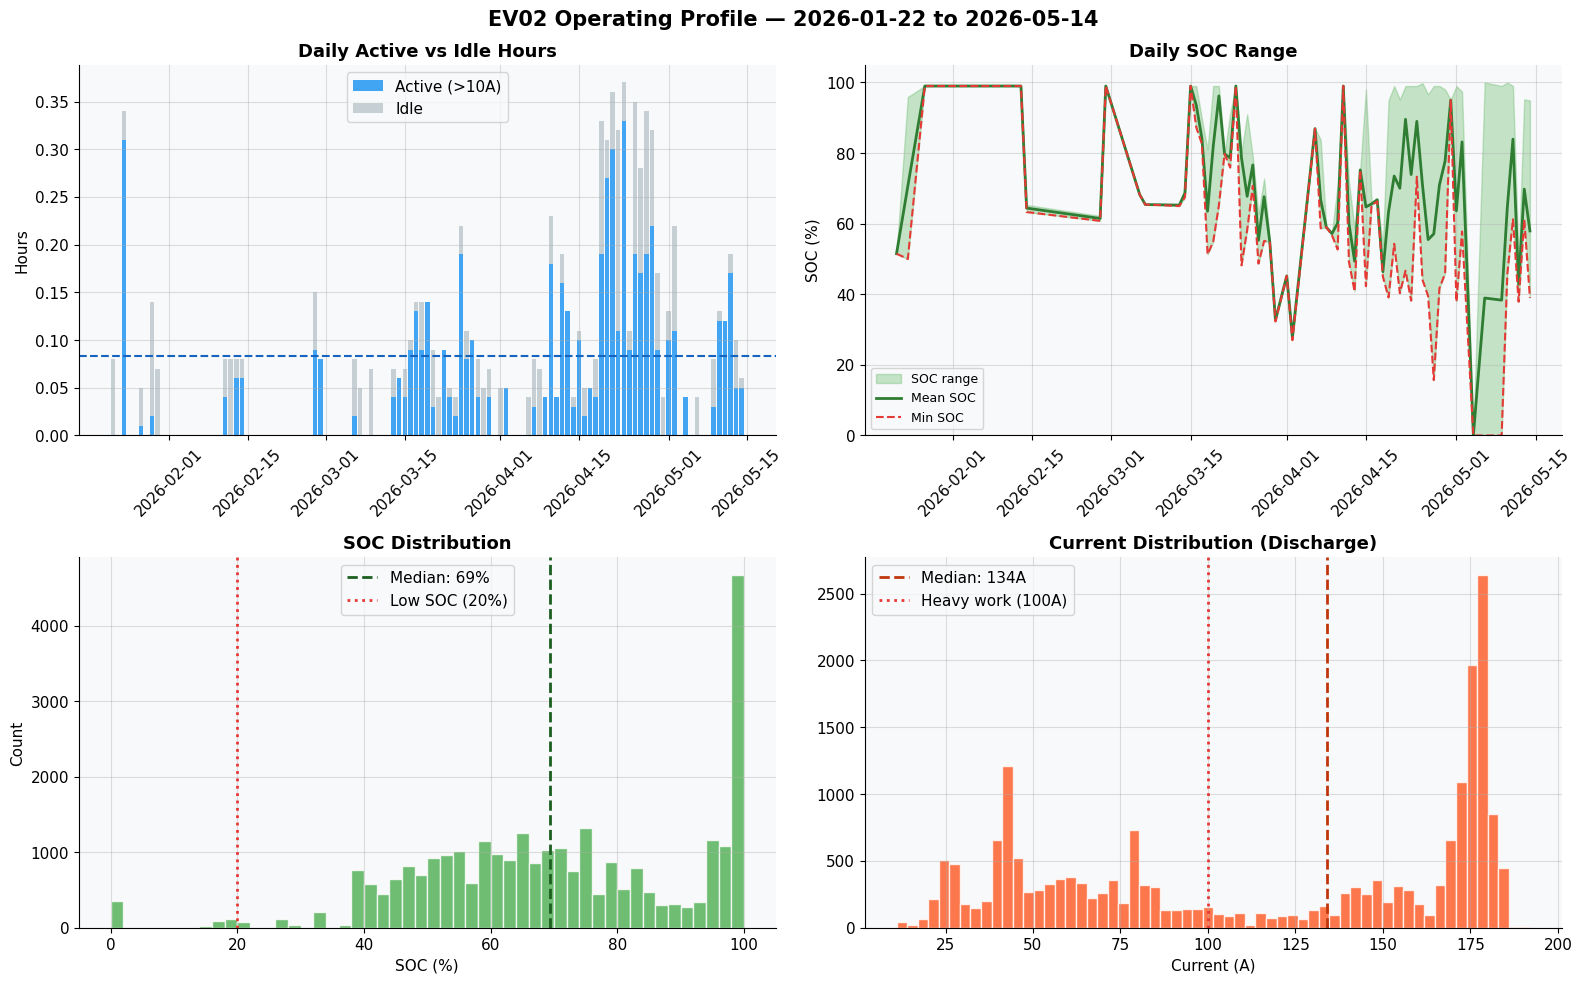

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f'EV02 Operating Profile — {df_clean["date"].min()} to {df_clean["date"].max()}')
dates = pd.to_datetime(daily['date'])

ax = axes[0, 0]
ax.bar(dates, daily['active_hours'], color='#2196F3', alpha=0.85, label='Active (>10A)')
ax.bar(dates, daily['idle_hours'], bottom=daily['active_hours'], color='#B0BEC5', alpha=0.7, label='Idle')
ax.axhline(daily['active_hours'].mean(), color='#1565C0', linestyle='--', linewidth=1.5)
ax.set_title('Daily Active vs Idle Hours'); ax.set_ylabel('Hours'); ax.legend()
ax.tick_params(axis='x', rotation=45)

ax = axes[0, 1]
ax.fill_between(dates, daily['soc_min'], daily['soc_max'], alpha=0.3, color='#4CAF50', label='SOC range')
ax.plot(dates, daily['soc_mean'], color='#2E7D32', linewidth=2, label='Mean SOC')
ax.plot(dates, daily['soc_min'], color='#E53935', linewidth=1.5, linestyle='--', label='Min SOC')
ax.set_title('Daily SOC Range'); ax.set_ylabel('SOC (%)'); ax.set_ylim(0, 105)
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=45)

ax = axes[1, 0]
ax.hist(df_clean['soc_pct'].dropna(), bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
ax.axvline(df_clean['soc_pct'].median(), color='#1B5E20', linestyle='--', linewidth=2,
           label=f"Median: {df_clean['soc_pct'].median():.0f}%")
ax.axvline(20, color='#E53935', linestyle=':', linewidth=2, label='Low SOC (20%)')
ax.set_title('SOC Distribution'); ax.set_xlabel('SOC (%)'); ax.set_ylabel('Count'); ax.legend()

ax = axes[1, 1]
discharge = df_clean[df_clean['operating_regime'].isin(['light_discharge', 'heavy_discharge'])]
ax.hist(discharge['battery_current_a'].dropna(), bins=60, color='#FF5722', alpha=0.8, edgecolor='white')
ax.axvline(discharge['battery_current_a'].median(), color='#BF360C', linestyle='--', linewidth=2,
           label=f"Median: {discharge['battery_current_a'].median():.0f}A")
ax.axvline(100, color='#E53935', linestyle=':', linewidth=2, label='Heavy work (100A)')
ax.set_title('Current Distribution (Discharge)'); ax.set_xlabel('Current (A)'); ax.legend()

plt.tight_layout()
Path('outputs/ev02').mkdir(parents=True, exist_ok=True)
plt.savefig('outputs/ev02/01_operating_profile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Battery Pack Health Overview

**What this does:** Shows pack-level health metrics over time.
**What to look for:** Cell spread trend vs 90mV warn / 130mV alert thresholds.

In [5]:
daily_health = df_clean.groupby('date').agg(
    mean_spread=('cell_spread_v', 'mean'),
    p95_spread=('cell_spread_v', lambda x: x.quantile(0.95)),
    max_spread=('cell_spread_v', 'max'),
    mean_temp_range=('pack_temp_range', 'mean'),
    p95_temp_range=('pack_temp_range', lambda x: x.quantile(0.95)),
    mean_pack_v_std=('pack_voltage_std', 'mean'),
    n=('cell_spread_v', 'count'),
).reset_index()
dates = pd.to_datetime(daily_health['date'])

print('=== PACK HEALTH SUMMARY ===')
print(f"Overall mean cell spread:      {df_clean['cell_spread_v'].mean()*1000:.1f} mV")
print(f"Overall p95 cell spread:       {df_clean['cell_spread_v'].quantile(0.95)*1000:.1f} mV")
print(f"Imbalance threshold (warn):    90 mV")
print(f"Imbalance threshold (alert):   130 mV")
print(f"% time above warn threshold:   {(df_clean['cell_spread_v'] > 0.09).mean()*100:.1f}%")
print(f"% time above alert threshold:  {(df_clean['cell_spread_v'] > 0.13).mean()*100:.1f}%")
print(f"Mean pack temp range:          {df_clean['pack_temp_range'].mean():.1f}°C")
print(f"Max pack temp range observed:  {df_clean['pack_temp_range'].max():.0f}°C")

=== PACK HEALTH SUMMARY ===
Overall mean cell spread:      64.9 mV
Overall p95 cell spread:       50.0 mV
Imbalance threshold (warn):    90 mV
Imbalance threshold (alert):   130 mV
% time above warn threshold:   1.1%
% time above alert threshold:  0.9%
Mean pack temp range:          19.4°C
Max pack temp range observed:  32°C


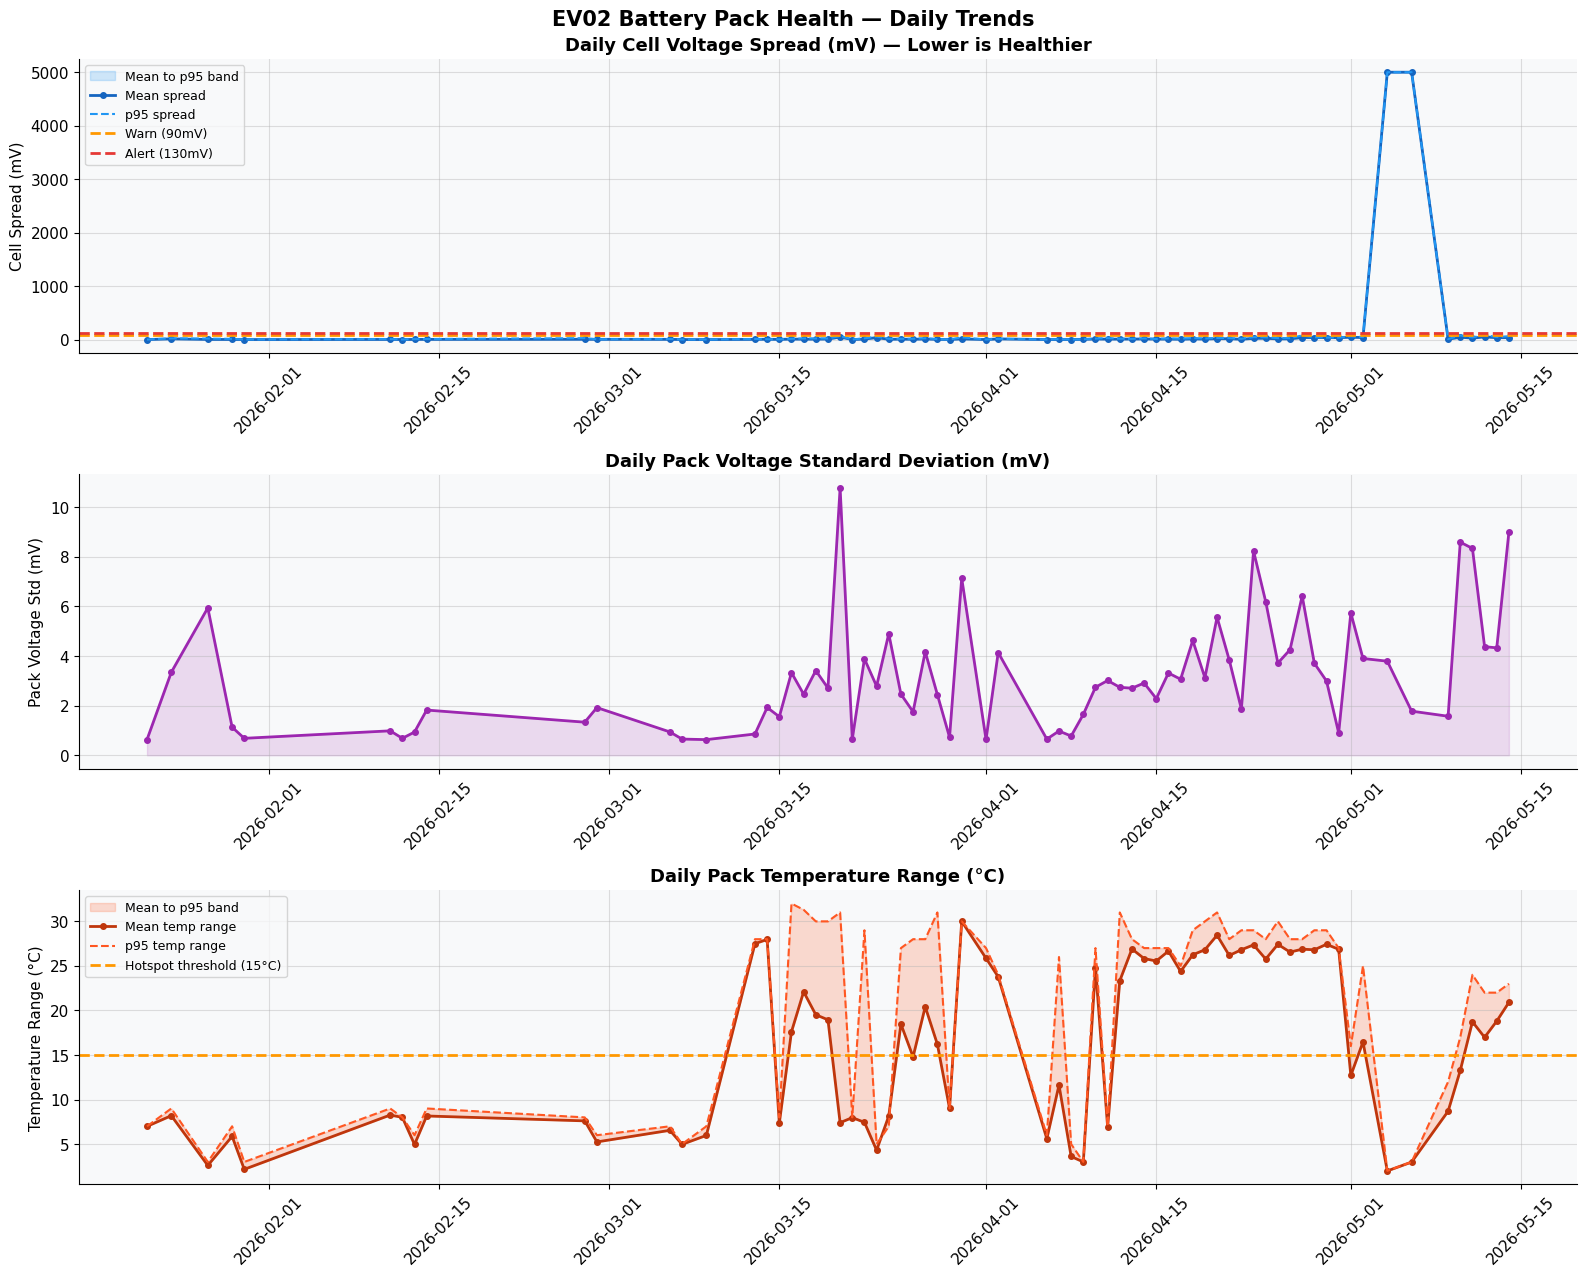

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('EV02 Battery Pack Health — Daily Trends')

ax = axes[0]
ax.fill_between(dates, daily_health['mean_spread']*1000, daily_health['p95_spread']*1000,
                alpha=0.2, color='#2196F3', label='Mean to p95 band')
ax.plot(dates, daily_health['mean_spread']*1000, color='#1565C0', linewidth=2, marker='o', markersize=4, label='Mean spread')
ax.plot(dates, daily_health['p95_spread']*1000, color='#2196F3', linewidth=1.5, linestyle='--', label='p95 spread')
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=2, label='Warn (90mV)')
ax.axhline(130, color='#E53935', linestyle='--', linewidth=2, label='Alert (130mV)')
ax.set_title('Daily Cell Voltage Spread (mV) — Lower is Healthier')
ax.set_ylabel('Cell Spread (mV)'); ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.plot(dates, daily_health['mean_pack_v_std']*1000, color='#9C27B0', linewidth=2, marker='o', markersize=4)
ax.fill_between(dates, 0, daily_health['mean_pack_v_std']*1000, alpha=0.15, color='#9C27B0')
ax.set_title('Daily Pack Voltage Standard Deviation (mV)')
ax.set_ylabel('Pack Voltage Std (mV)'); ax.tick_params(axis='x', rotation=45)

ax = axes[2]
ax.fill_between(dates, daily_health['mean_temp_range'], daily_health['p95_temp_range'],
                alpha=0.2, color='#FF5722', label='Mean to p95 band')
ax.plot(dates, daily_health['mean_temp_range'], color='#BF360C', linewidth=2, marker='o', markersize=4, label='Mean temp range')
ax.plot(dates, daily_health['p95_temp_range'], color='#FF5722', linewidth=1.5, linestyle='--', label='p95 temp range')
ax.axhline(15, color='#FF9800', linestyle='--', linewidth=2, label='Hotspot threshold (15°C)')
ax.set_title('Daily Pack Temperature Range (°C)')
ax.set_ylabel('Temperature Range (°C)'); ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('outputs/ev02/02_pack_health_daily.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Module-by-Module Comparison

**What this does:** Compares all 5 modules across temperature, voltage, and imbalance metrics.
**What to look for:** Which module is consistently hottest and/or lowest voltage.

In [7]:
module_stats = []
for i in range(1, 6):
    module_stats.append({
        'Module': f'Module {i}',
        'Mean Voltage (V)': df_clean[f'module_{i}_voltage_mean'].mean(),
        'Voltage Std (mV)': df_clean[f'module_{i}_voltage_std'].mean() * 1000,
        'Voltage Range (mV)': df_clean[f'module_{i}_voltage_range'].mean() * 1000,
        'Mean Temp (°C)': df_clean[f'module_{i}_temp_mean'].mean(),
        'Temp Range (°C)': df_clean[f'module_{i}_temp_range'].mean(),
        'Hottest (% time)': (df_clean['hottest_module'] == i).mean() * 100,
        'Lowest Voltage (% time)': (df_clean['lowest_voltage_module'] == i).mean() * 100,
    })

module_df = pd.DataFrame(module_stats)
print('=== MODULE COMPARISON TABLE ===')
print(module_df.round(3).to_string(index=False))
hot_mod = int(module_df['Hottest (% time)'].idxmax()) + 1
low_mod = int(module_df['Lowest Voltage (% time)'].idxmax()) + 1
print(f'\n→ Hottest module: Module {hot_mod} ({module_df["Hottest (% time)"].max():.1f}% of time)')
print(f'→ Lowest voltage module: Module {low_mod} ({module_df["Lowest Voltage (% time)"].max():.1f}% of time)')

=== MODULE COMPARISON TABLE ===
  Module  Mean Voltage (V)  Voltage Std (mV)  Voltage Range (mV)  Mean Temp (°C)  Temp Range (°C)  Hottest (% time)  Lowest Voltage (% time)
Module 1             3.321             1.854               6.299          32.929            5.983            32.629                   16.056
Module 2             3.322             1.844               6.678          37.222            3.747            28.444                   26.936
Module 3             3.322             1.717               5.682          37.067            3.782            37.689                    4.264
Module 4             3.321             1.640               5.530          35.268           16.065             1.023                   22.817
Module 5             3.323             2.109               7.014          30.368            6.517             0.206                   29.917

→ Hottest module: Module 3 (37.7% of time)
→ Lowest voltage module: Module 5 (29.9% of time)


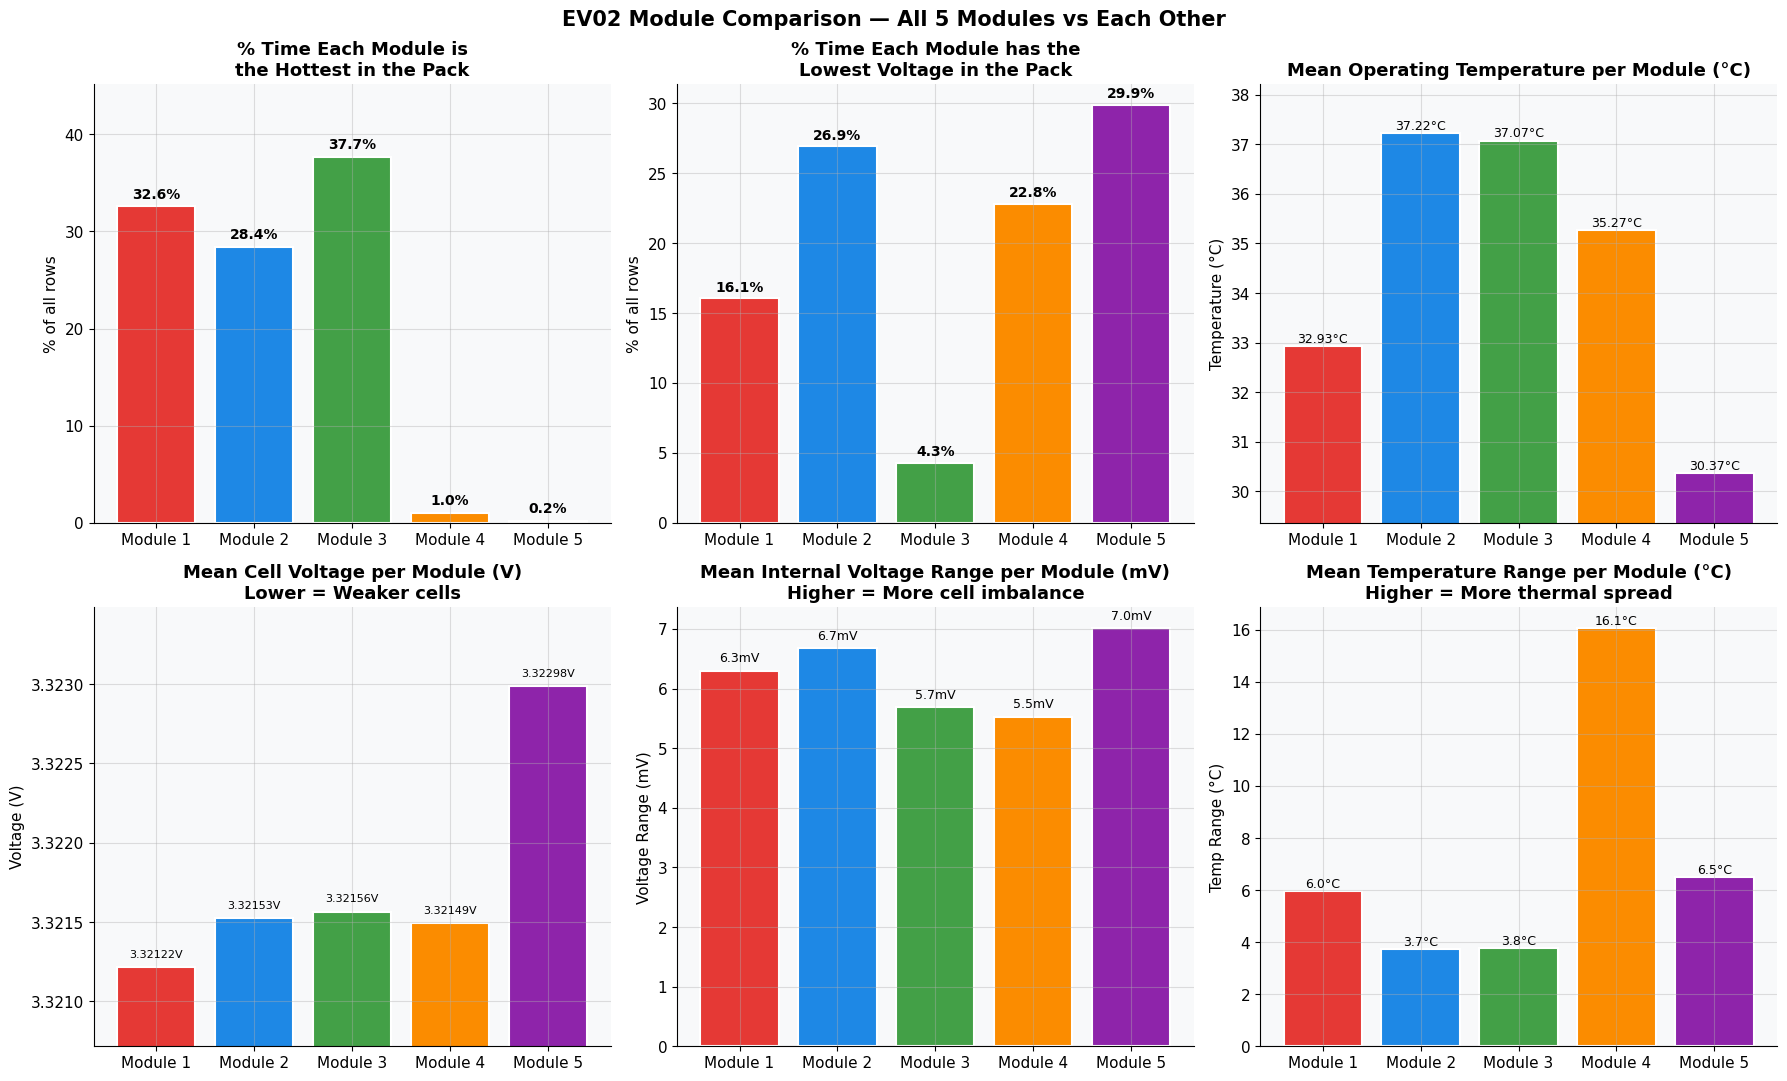

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('EV02 Module Comparison — All 5 Modules vs Each Other')
modules = [f'Module {i}' for i in range(1, 6)]
colors = [MODULE_COLORS[i] for i in range(1, 6)]

ax = axes[0, 0]
vals = [module_df.loc[i, 'Hottest (% time)'] for i in range(5)]
bars = ax.bar(modules, vals, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('% Time Each Module is\nthe Hottest in the Pack'); ax.set_ylabel('% of all rows')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(0, max(vals) * 1.2)

ax = axes[0, 1]
vals = [module_df.loc[i, 'Lowest Voltage (% time)'] for i in range(5)]
bars = ax.bar(modules, vals, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('% Time Each Module has the\nLowest Voltage in the Pack'); ax.set_ylabel('% of all rows')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[0, 2]
vals = [module_df.loc[i, 'Mean Temp (°C)'] for i in range(5)]
bars = ax.bar(modules, vals, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Mean Operating Temperature per Module (°C)'); ax.set_ylabel('Temperature (°C)')
ax.set_ylim(min(vals) - 1, max(vals) + 1)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}°C', ha='center', va='bottom', fontsize=9)

ax = axes[1, 0]
vals = [module_df.loc[i, 'Mean Voltage (V)'] for i in range(5)]
bars = ax.bar(modules, vals, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Mean Cell Voltage per Module (V)\nLower = Weaker cells'); ax.set_ylabel('Voltage (V)')
ax.set_ylim(min(vals) - 0.0005, max(vals) + 0.0005)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00005,
            f'{val:.5f}V', ha='center', va='bottom', fontsize=8)

ax = axes[1, 1]
vals = [module_df.loc[i, 'Voltage Range (mV)'] for i in range(5)]
bars = ax.bar(modules, vals, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Mean Internal Voltage Range per Module (mV)\nHigher = More cell imbalance')
ax.set_ylabel('Voltage Range (mV)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}mV', ha='center', va='bottom', fontsize=9)

ax = axes[1, 2]
vals = [module_df.loc[i, 'Temp Range (°C)'] for i in range(5)]
bars = ax.bar(modules, vals, color=colors, edgecolor='white', linewidth=1.5)
ax.set_title('Mean Temperature Range per Module (°C)\nHigher = More thermal spread')
ax.set_ylabel('Temp Range (°C)')
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.1f}°C', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/ev02/03_module_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Dominant Module Deep Dive

**What this does:** Deep-dives into the hottest/weakest module.
**What to look for:** Does the dominance hold across all SOC bands and current levels?

In [9]:
# Module dominance by SOC band
soc_mod = df_clean.assign(
    mod_hot=(df_clean['hottest_module'] == hot_mod),
    mod_low=(df_clean['lowest_voltage_module'] == hot_mod)
).groupby('soc_band', observed=False).agg(
    pct_mod_hot=('mod_hot', 'mean'),
    pct_mod_low=('mod_low', 'mean'),
    mean_spread=('cell_spread_v', 'mean'),
    n=('cell_spread_v', 'size')
).reset_index()

df_clean['current_bin'] = pd.cut(df_clean['abs_current_a'],
                                  bins=[0, 10, 50, 100, 150, float('inf')],
                                  labels=['Idle (<10A)', 'Low (10-50A)', 'Med (50-100A)', 'High (100-150A)', 'Max (>150A)'],
                                  include_lowest=True)
cur_mod = df_clean.assign(
    mod_hot=(df_clean['hottest_module'] == hot_mod),
    mod_low=(df_clean['lowest_voltage_module'] == hot_mod)
).groupby('current_bin', observed=False).agg(
    pct_mod_hot=('mod_hot', 'mean'),
    pct_mod_low=('mod_low', 'mean'),
    mean_spread=('cell_spread_v', 'mean'),
    n=('cell_spread_v', 'size')
).reset_index()

print(f'Module {hot_mod} dominance by SOC band:')
print(soc_mod[['soc_band', 'pct_mod_hot', 'pct_mod_low', 'mean_spread', 'n']].round(3).to_string(index=False))
print(f'\nModule {hot_mod} dominance by current level:')
print(cur_mod[['current_bin', 'pct_mod_hot', 'pct_mod_low', 'mean_spread', 'n']].round(3).to_string(index=False))

Module 3 dominance by SOC band:
soc_band  pct_mod_hot  pct_mod_low  mean_spread    n
    0-20        0.403        0.063        1.703  600
   20-40        0.654        0.028        0.025 1234
   40-60        0.367        0.043        0.021 7880
   60-80        0.292        0.037        0.016 9401
  80-100        0.465        0.039        0.043 9944

Module 3 dominance by current level:
    current_bin  pct_mod_hot  pct_mod_low  mean_spread     n
    Idle (<10A)        0.402        0.049        0.078 10734
   Low (10-50A)        0.303        0.056        0.087  4513
  Med (50-100A)        0.448        0.038        0.081  4746
High (100-150A)        0.582        0.043        0.066  2338
    Max (>150A)        0.297        0.031        0.030  9030


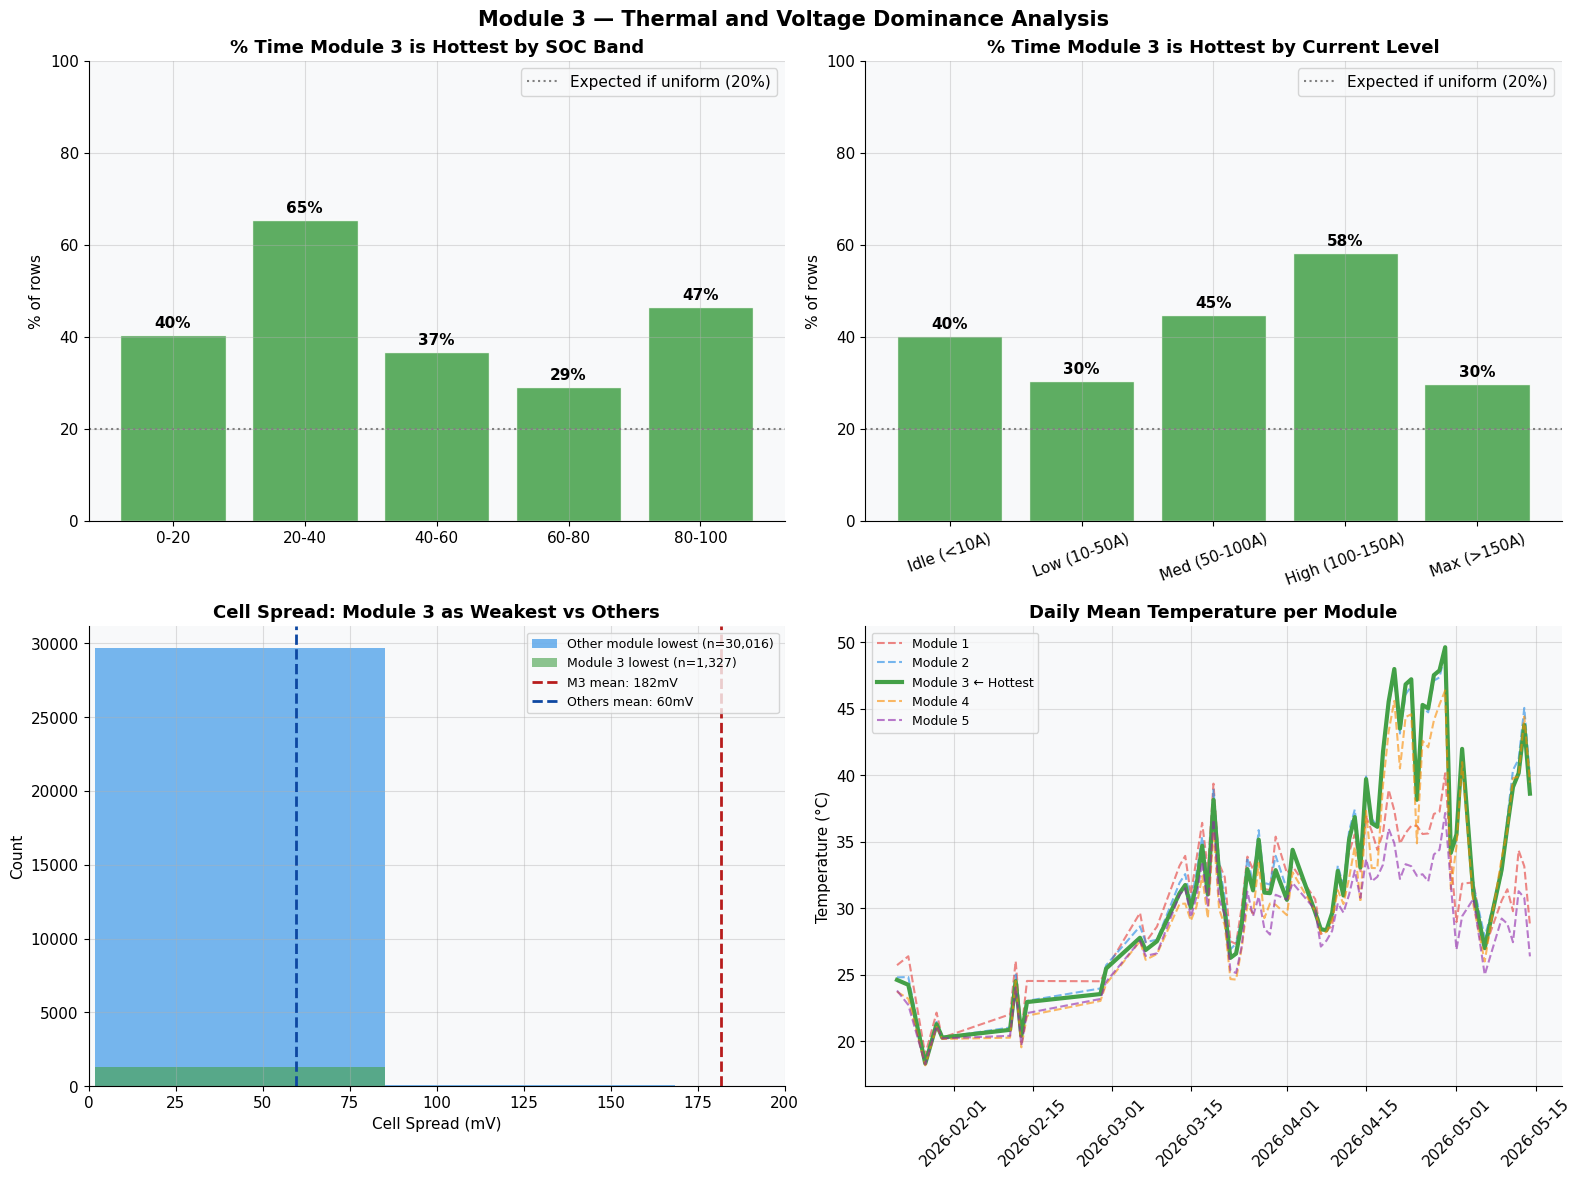

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'Module {hot_mod} — Thermal and Voltage Dominance Analysis')
soc_labels = soc_mod['soc_band'].astype(str).tolist()
cur_labels = cur_mod['current_bin'].astype(str).tolist()
x = np.arange(len(soc_labels)); xc = np.arange(len(cur_labels))

ax = axes[0, 0]
bars = ax.bar(x, soc_mod['pct_mod_hot']*100, color=MODULE_COLORS[hot_mod], alpha=0.85, edgecolor='white')
ax.axhline(20, color='gray', linestyle=':', linewidth=1.5, label='Expected if uniform (20%)')
ax.set_xticks(x); ax.set_xticklabels(soc_labels)
ax.set_title(f'% Time Module {hot_mod} is Hottest by SOC Band')
ax.set_ylabel('% of rows'); ax.set_ylim(0, 100); ax.legend()
for bar, val in zip(bars, soc_mod['pct_mod_hot']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val*100:.0f}%', ha='center', va='bottom', fontweight='bold')

ax = axes[0, 1]
bars = ax.bar(xc, cur_mod['pct_mod_hot']*100, color=MODULE_COLORS[hot_mod], alpha=0.85, edgecolor='white')
ax.axhline(20, color='gray', linestyle=':', linewidth=1.5, label='Expected if uniform (20%)')
ax.set_xticks(xc); ax.set_xticklabels(cur_labels, rotation=20)
ax.set_title(f'% Time Module {hot_mod} is Hottest by Current Level')
ax.set_ylabel('% of rows'); ax.set_ylim(0, 100); ax.legend()
for bar, val in zip(bars, cur_mod['pct_mod_hot']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val*100:.0f}%', ha='center', va='bottom', fontweight='bold')

ax = axes[1, 0]
m_low = df_clean[df_clean['lowest_voltage_module']==hot_mod]['cell_spread_v'].dropna()*1000
m_oth = df_clean[df_clean['lowest_voltage_module']!=hot_mod]['cell_spread_v'].dropna()*1000
ax.hist(m_oth, bins=60, alpha=0.6, color='#1E88E5', label=f'Other module lowest (n={len(m_oth):,})')
ax.hist(m_low, bins=60, alpha=0.6, color=MODULE_COLORS[hot_mod], label=f'Module {hot_mod} lowest (n={len(m_low):,})')
ax.axvline(m_low.mean(), color='#B71C1C', linestyle='--', linewidth=2, label=f'M{hot_mod} mean: {m_low.mean():.0f}mV')
ax.axvline(m_oth.mean(), color='#0D47A1', linestyle='--', linewidth=2, label=f'Others mean: {m_oth.mean():.0f}mV')
ax.set_title(f'Cell Spread: Module {hot_mod} as Weakest vs Others')
ax.set_xlabel('Cell Spread (mV)'); ax.set_ylabel('Count'); ax.legend(fontsize=9); ax.set_xlim(0, 200)

ax = axes[1, 1]
daily_temps = df_clean.groupby('date')[[f'module_{i}_temp_mean' for i in range(1, 6)]].mean().reset_index()
dates_t = pd.to_datetime(daily_temps['date'])
for i in range(1, 6):
    lw = 3 if i == hot_mod else 1.5; alpha = 1.0 if i == hot_mod else 0.6
    ls = '-' if i == hot_mod else '--'
    label = f'Module {i}' + (' ← Hottest' if i == hot_mod else '')
    ax.plot(dates_t, daily_temps[f'module_{i}_temp_mean'],
            color=MODULE_COLORS[i], linewidth=lw, alpha=alpha, linestyle=ls, label=label)
ax.set_title('Daily Mean Temperature per Module')
ax.set_ylabel('Temperature (°C)'); ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'outputs/ev02/04_module{hot_mod}_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 6 — Degraded Cells: Worst Cell Analysis

**What this does:** Tracks which specific cell positions are chronically the weakest across the pack.
**What to look for:** Persistent worst-cell patterns repeating across multiple days and modules.

In [11]:
print('=== WORST CELL ID FREQUENCY (top 20) ===')
print(df_clean['worst_cell_id'].value_counts().head(20).to_string())
print()
print('=== LOWEST CELL per MODULE (top 5 each) ===')
for i in range(1, 6):
    col = f'module_{i}_lowest_cell'
    if col in df_clean.columns:
        print(f'Module {i}: {dict(df_clean[col].value_counts().head(5))}')

=== WORST CELL ID FREQUENCY (top 20) ===
worst_cell_id
M2_C24    8527
M1_C1     6666
M5_C9     2681
M2_C9     1295
M4_C9     1059
M5_C15     863
M3_C24     800
M5_C13     746
M4_C5      737
M1_C7      670
M2_C8      523
M4_C2      419
M3_C9      416
M5_C5      385
M4_C1      314
M1_C13     313
M4_C7      271
M1_C11     247
M3_C23     224
M4_C24     220

=== LOWEST CELL per MODULE (top 5 each) ===
Module 1: {'M1_C1': 22059, 'M1_C7': 3458, 'M1_C13': 1345, 'M1_C11': 921, 'M1_C9': 654}
Module 2: {'M2_C24': 12718, 'M2_C9': 7174, 'M2_C8': 2652, 'M2_C1': 1874, 'M2_C5': 1835}
Module 3: {'M3_C9': 12513, 'M3_C24': 5520, 'M3_C1': 5304, 'M3_C23': 1638, 'M3_C14': 1595}
Module 4: {'M4_C9': 14481, 'M4_C1': 7521, 'M4_C5': 2672, 'M4_C8': 1301, 'M4_C2': 1040}
Module 5: {'M5_C9': 19494, 'M5_C1': 2800, 'M5_C19': 1531, 'M5_C13': 1407, 'M5_C15': 1189}


In [12]:
# Identify top 2 worst cell positions dynamically
top_cells = df_clean['worst_cell_id'].value_counts().head(2).index.tolist()
c1 = top_cells[0] if len(top_cells) > 0 else 'C1'
c2 = top_cells[1] if len(top_cells) > 1 else 'C2'
c1_pos = c1.split('_')[-1] if '_' in str(c1) else str(c1)
c2_pos = c2.split('_')[-1] if '_' in str(c2) else str(c2)

df_clean['is_c1_worst'] = df_clean['worst_cell_id'].astype(str).str.contains(c1_pos, na=False)
df_clean['is_c2_worst'] = df_clean['worst_cell_id'].astype(str).str.contains(c2_pos, na=False)
df_clean['is_hot_mod_worst'] = df_clean['worst_cell_id'].astype(str).str.startswith(f'M{hot_mod}', na=False)

daily_cells = df_clean.groupby('date').agg(
    pct_c1_worst=('is_c1_worst', 'mean'),
    pct_c2_worst=('is_c2_worst', 'mean'),
    pct_hot_mod_worst=('is_hot_mod_worst', 'mean'),
    mean_spread=('cell_spread_v', 'mean'),
    n=('cell_spread_v', 'count')
).reset_index()

print(f'=== WORST CELL POSITIONS: {c1_pos} and {c2_pos} ===')
print(f'% time {c1_pos} is worst cell in pack: {df_clean["is_c1_worst"].mean()*100:.1f}%')
print(f'% time {c2_pos} is worst cell in pack: {df_clean["is_c2_worst"].mean()*100:.1f}%')
print(f'% time a Module {hot_mod} cell is worst: {df_clean["is_hot_mod_worst"].mean()*100:.1f}%')

=== WORST CELL POSITIONS: C24 and C1 ===
% time C24 is worst cell in pack: 30.3%
% time C1 is worst cell in pack: 36.3%
% time a Module 3 cell is worst: 5.6%


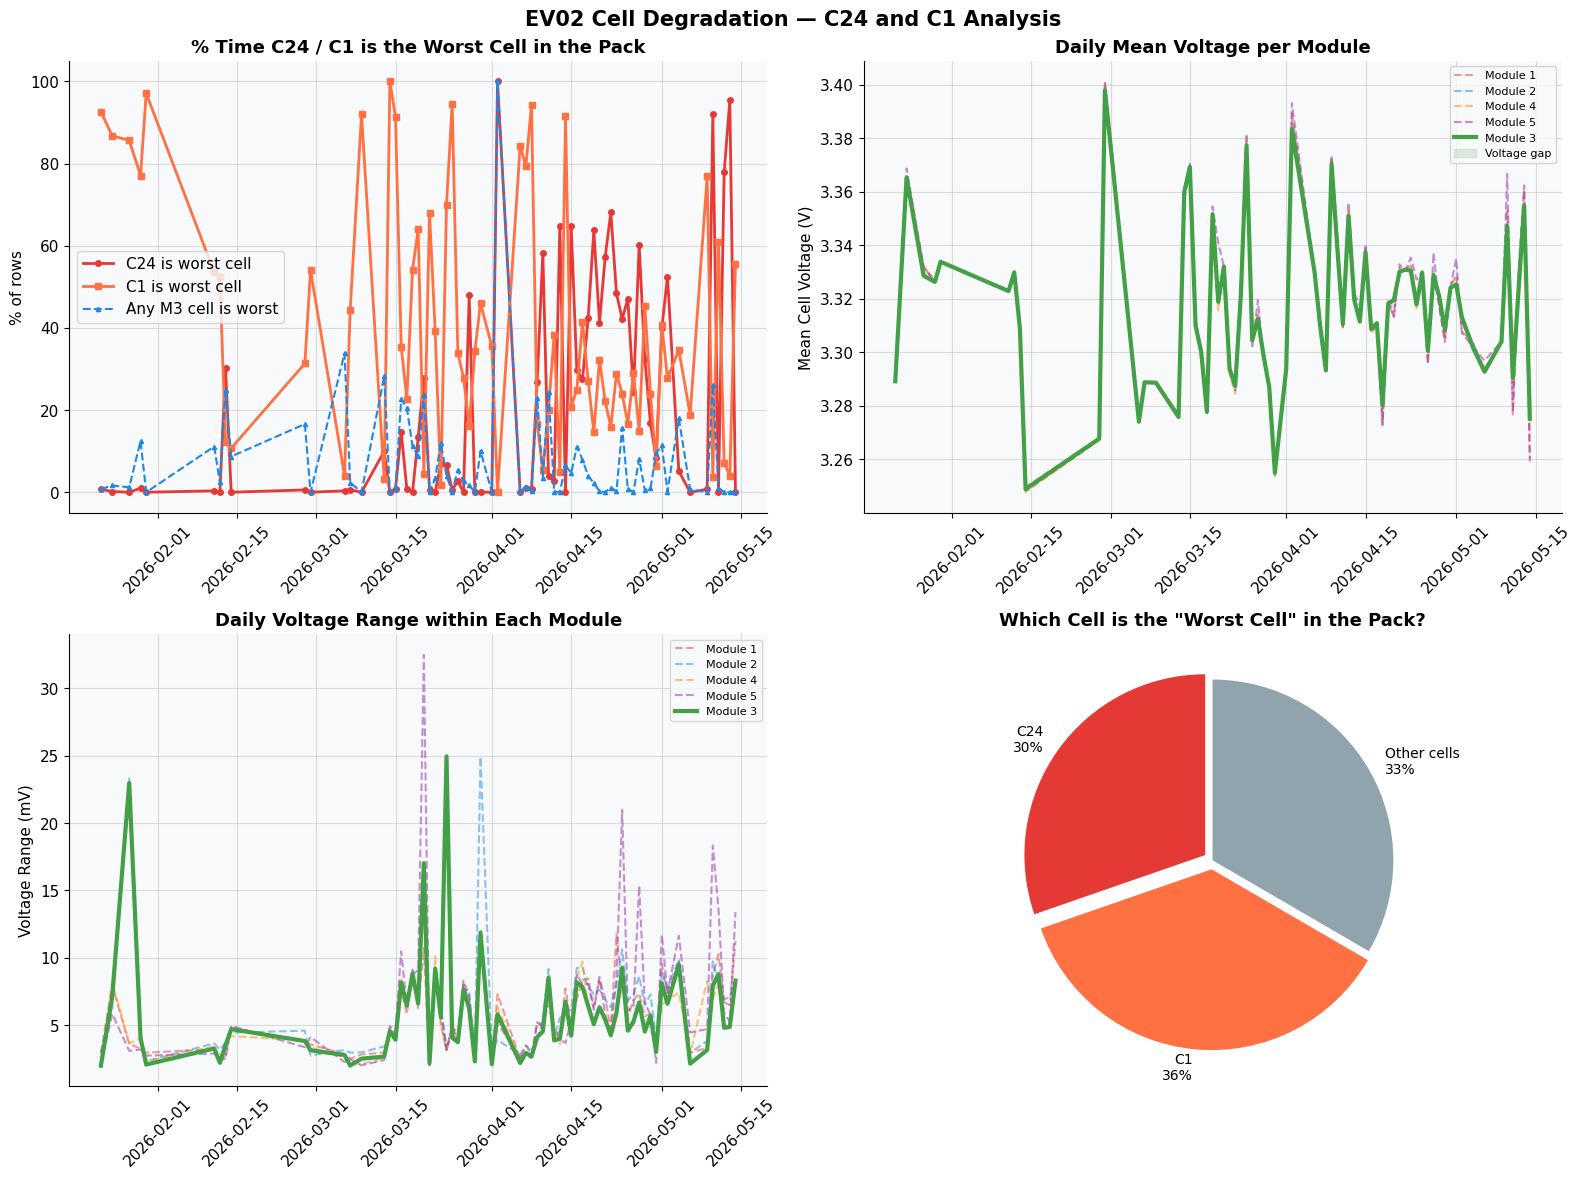

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'EV02 Cell Degradation — {c1_pos} and {c2_pos} Analysis')
dates_c = pd.to_datetime(daily_cells['date'])

ax = axes[0, 0]
ax.plot(dates_c, daily_cells['pct_c1_worst']*100, color='#E53935', linewidth=2, marker='o', markersize=4, label=f'{c1_pos} is worst cell')
ax.plot(dates_c, daily_cells['pct_c2_worst']*100, color='#FF7043', linewidth=2, marker='s', markersize=4, label=f'{c2_pos} is worst cell')
ax.plot(dates_c, daily_cells['pct_hot_mod_worst']*100, color='#1E88E5', linewidth=1.5, linestyle='--', marker='^', markersize=3, label=f'Any M{hot_mod} cell is worst')
ax.set_title(f'% Time {c1_pos} / {c2_pos} is the Worst Cell in the Pack')
ax.set_ylabel('% of rows'); ax.legend(); ax.tick_params(axis='x', rotation=45)

ax = axes[0, 1]
daily_mod_v = df_clean.groupby('date')[[f'module_{i}_voltage_mean' for i in range(1, 6)]].mean().reset_index()
dates_v = pd.to_datetime(daily_mod_v['date'])
for i in range(1, 6):
    if i != hot_mod:
        ax.plot(dates_v, daily_mod_v[f'module_{i}_voltage_mean'], color=MODULE_COLORS[i], linewidth=1.5, alpha=0.5, linestyle='--', label=f'Module {i}')
ax.plot(dates_v, daily_mod_v[f'module_{hot_mod}_voltage_mean'], color=MODULE_COLORS[hot_mod], linewidth=3, label=f'Module {hot_mod}')
others_mean = daily_mod_v[[f'module_{i}_voltage_mean' for i in range(1, 6) if i != hot_mod]].mean(axis=1)
ax.fill_between(dates_v, daily_mod_v[f'module_{hot_mod}_voltage_mean'], others_mean, alpha=0.15, color=MODULE_COLORS[hot_mod], label='Voltage gap')
ax.set_title('Daily Mean Voltage per Module'); ax.set_ylabel('Mean Cell Voltage (V)')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=45)

ax = axes[1, 0]
daily_mod_r = df_clean.groupby('date')[[f'module_{i}_voltage_range' for i in range(1, 6)]].mean().reset_index()
dates_r = pd.to_datetime(daily_mod_r['date'])
for i in range(1, 6):
    if i != hot_mod:
        ax.plot(dates_r, daily_mod_r[f'module_{i}_voltage_range']*1000, color=MODULE_COLORS[i], linewidth=1.5, alpha=0.5, linestyle='--', label=f'Module {i}')
ax.plot(dates_r, daily_mod_r[f'module_{hot_mod}_voltage_range']*1000, color=MODULE_COLORS[hot_mod], linewidth=3, label=f'Module {hot_mod}')
ax.set_title('Daily Voltage Range within Each Module'); ax.set_ylabel('Voltage Range (mV)')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=45)

ax = axes[1, 1]
c1_total = int(df_clean['is_c1_worst'].sum())
c2_total = int(df_clean['is_c2_worst'].sum())
other_total = len(df_clean) - c1_total - c2_total
ax.pie([c1_total, c2_total, other_total],
       labels=[f'{c1_pos}\n{c1_total/len(df_clean)*100:.0f}%', f'{c2_pos}\n{c2_total/len(df_clean)*100:.0f}%', f'Other cells\n{other_total/len(df_clean)*100:.0f}%'],
       colors=['#E53935', '#FF7043', '#90A4AE'], explode=[0.05, 0.05, 0],
       autopct='', startangle=90, textprops={'fontsize': 10})
ax.set_title('Which Cell is the "Worst Cell" in the Pack?')

plt.tight_layout()
plt.savefig('outputs/ev02/05_cell_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7 — When Does Imbalance Get Worse?

**What this does:** Tests whether cell imbalance is driven by operating conditions or is structural.
**What to look for:** If correlation with current is near zero, imbalance is structural (cell degradation).

In [14]:
spread_by_soc = df_clean.groupby(['soc_band', 'current_direction'], observed=False)['cell_spread_v'].agg(
    mean='mean', p95=lambda x: x.quantile(0.95), n='size'
).reset_index()

corr_signals = ['cell_spread_v', 'pack_voltage_std', 'pack_temp_range', 'abs_current_a', 'soc_pct']
corr_matrix = df_clean[corr_signals].dropna().corr()
spread_cur_corr = corr_matrix.loc['cell_spread_v', 'abs_current_a']
spread_soc_corr = corr_matrix.loc['cell_spread_v', 'soc_pct']

print('=== CELL SPREAD BY SOC AND CURRENT DIRECTION ===')
print(spread_by_soc.round(4).to_string(index=False))
print('\n=== CORRELATION MATRIX ===')
print(corr_matrix.round(3).to_string())
print(f'\nKey correlation — cell_spread vs abs_current: {spread_cur_corr:.3f}')
print(f'Key correlation — cell_spread vs soc_pct:    {spread_soc_corr:.3f}')
if abs(spread_cur_corr) < 0.05:
    print('→ Near-zero correlation with current: imbalance is structural (cell degradation).')
else:
    print(f'→ Current has moderate influence on spread (r={spread_cur_corr:.2f}) — monitor heavy load.')

=== CELL SPREAD BY SOC AND CURRENT DIRECTION ===
soc_band current_direction   mean   p95    n
    0-20            charge    NaN   NaN    0
    0-20              idle 1.5465 4.999  224
    0-20         discharge 1.7964 4.999  376
   20-40            charge    NaN   NaN    0
   20-40              idle 0.0190 0.066  397
   20-40         discharge 0.0284 0.071  837
   40-60            charge    NaN   NaN    0
   40-60              idle 0.0145 0.042 2117
   40-60         discharge 0.0237 0.049 5763
   60-80            charge    NaN   NaN    0
   60-80              idle 0.0123 0.039 2708
   60-80         discharge 0.0171 0.042 6693
  80-100            charge    NaN   NaN    0
  80-100              idle 0.0780 0.081 3641
  80-100         discharge 0.0226 0.054 6303

=== CORRELATION MATRIX ===
                  cell_spread_v  pack_voltage_std  pack_temp_range  abs_current_a  soc_pct
cell_spread_v             1.000             0.001           -0.163         -0.043   -0.225
pack_voltage_std     

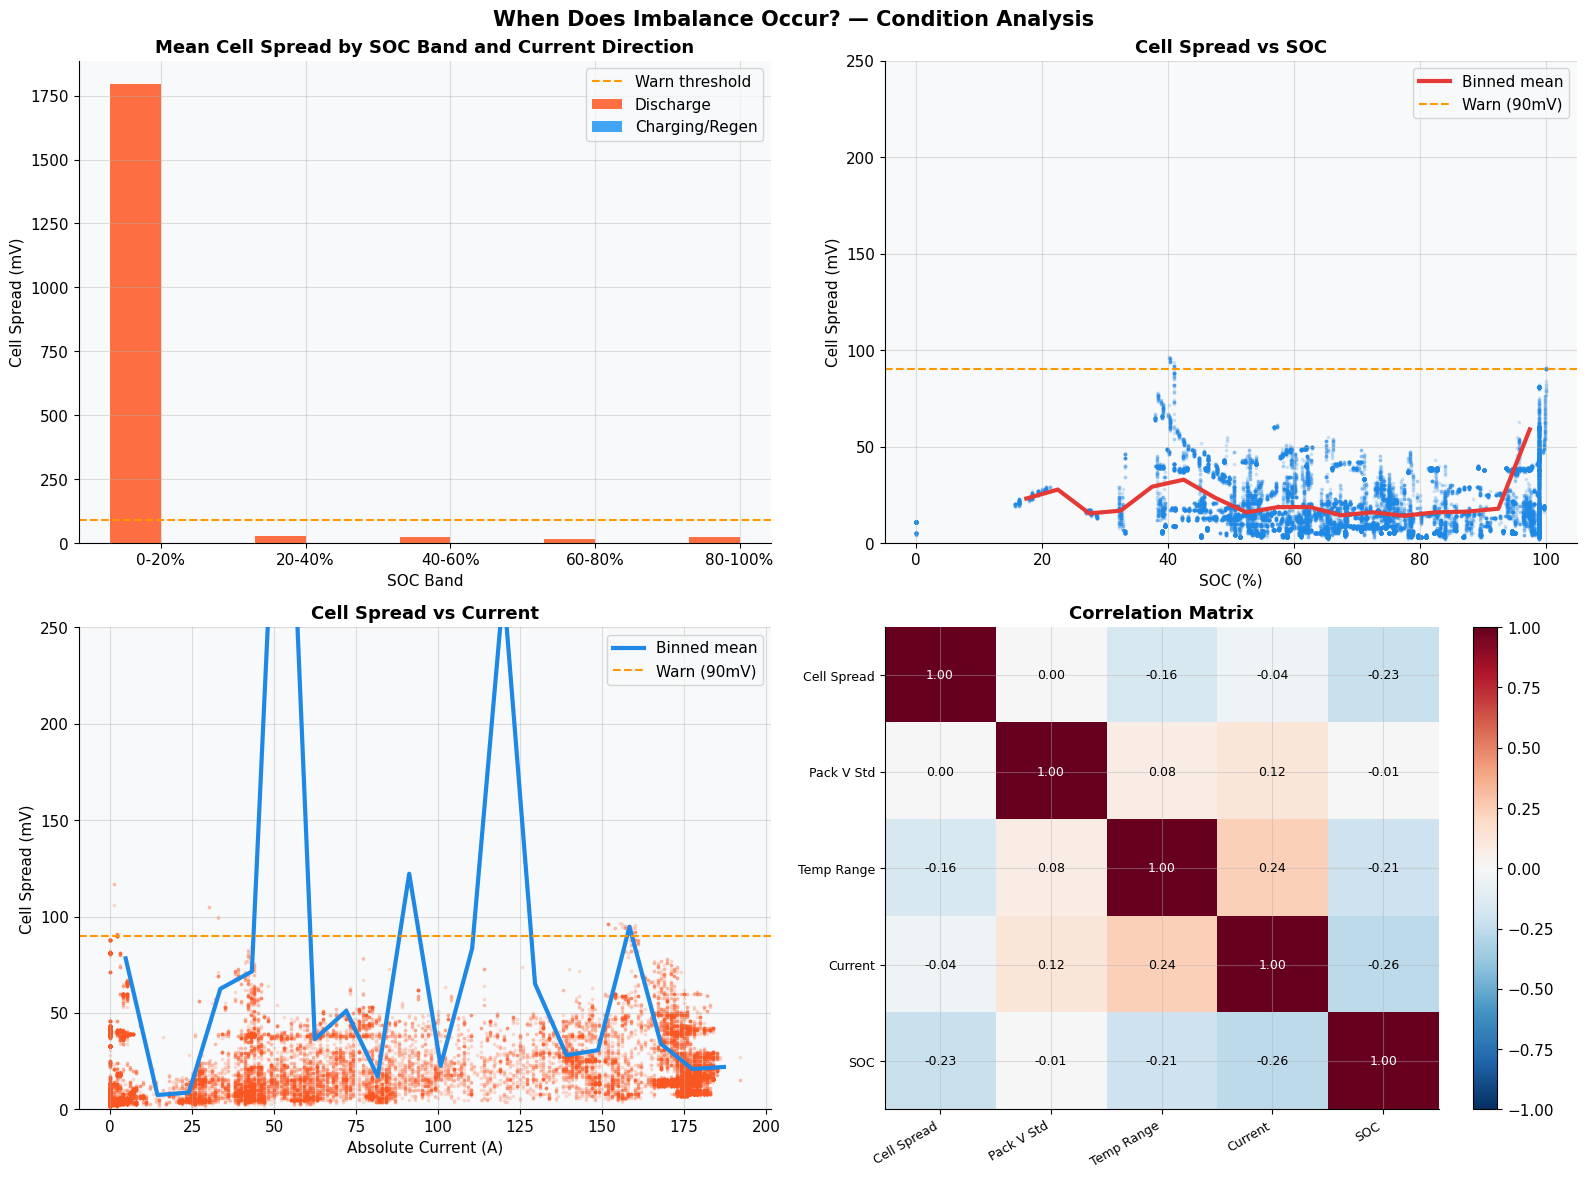

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('When Does Imbalance Occur? — Condition Analysis')

ax = axes[0, 0]
soc_discharge = spread_by_soc[spread_by_soc['current_direction'] == 'discharge']
soc_charge = spread_by_soc[spread_by_soc['current_direction'] == 'charge']
x_labels = ['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
x = np.arange(len(x_labels)); width = 0.35
if len(soc_discharge) == 5: ax.bar(x - width/2, soc_discharge['mean']*1000, width, color='#FF5722', alpha=0.85, label='Discharge')
if len(soc_charge) == 5: ax.bar(x + width/2, soc_charge['mean']*1000, width, color='#2196F3', alpha=0.85, label='Charging/Regen')
ax.set_xticks(x); ax.set_xticklabels(x_labels)
ax.set_title('Mean Cell Spread by SOC Band and Current Direction')
ax.set_xlabel('SOC Band'); ax.set_ylabel('Cell Spread (mV)')
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=1.5, label='Warn threshold'); ax.legend()

ax = axes[0, 1]
sample = df_clean.sample(min(80000, len(df_clean)), random_state=42)
ax.scatter(sample['soc_pct'], sample['cell_spread_v']*1000, s=3, alpha=0.15, color='#1E88E5')
soc_bins = pd.cut(sample['soc_pct'], bins=20)
soc_mean_spread = sample.groupby(soc_bins, observed=False)['cell_spread_v'].mean()*1000
ax.plot([i.mid for i in soc_mean_spread.index], soc_mean_spread.values, color='#E53935', linewidth=3, label='Binned mean')
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=1.5, label='Warn (90mV)')
ax.set_title('Cell Spread vs SOC'); ax.set_xlabel('SOC (%)'); ax.set_ylabel('Cell Spread (mV)')
ax.set_ylim(0, 250); ax.legend()

ax = axes[1, 0]
ax.scatter(sample['abs_current_a'], sample['cell_spread_v']*1000, s=3, alpha=0.15, color='#FF5722')
cur_bins = pd.cut(sample['abs_current_a'], bins=20)
cur_mean_spread = sample.groupby(cur_bins, observed=False)['cell_spread_v'].mean()*1000
ax.plot([i.mid for i in cur_mean_spread.index], cur_mean_spread.values, color='#1E88E5', linewidth=3, label='Binned mean')
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=1.5, label='Warn (90mV)')
ax.set_title('Cell Spread vs Current'); ax.set_xlabel('Absolute Current (A)'); ax.set_ylabel('Cell Spread (mV)')
ax.set_ylim(0, 250); ax.legend()

ax = axes[1, 1]
corr_display = corr_matrix.copy()
corr_display.index = ['Cell Spread', 'Pack V Std', 'Temp Range', 'Current', 'SOC']
corr_display.columns = ['Cell Spread', 'Pack V Std', 'Temp Range', 'Current', 'SOC']
im = ax.imshow(corr_display.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_display.columns))); ax.set_yticks(range(len(corr_display.index)))
ax.set_xticklabels(corr_display.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(corr_display.index, fontsize=9)
for i in range(len(corr_display)):
    for j in range(len(corr_display.columns)):
        val = corr_display.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color='white' if abs(val) > 0.5 else 'black', fontsize=9)
plt.colorbar(im, ax=ax); ax.set_title('Correlation Matrix')

plt.tight_layout()
plt.savefig('outputs/ev02/06_imbalance_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — The Worst Operating Condition

**What this does:** Identifies the highest-stress scenario for the battery.
**What to look for:** Does the worst combination push spread above the warn threshold?

In [16]:
work_threshold = df_clean['abs_current_a'].quantile(0.70)
working = df_clean[
    (df_clean['abs_current_a'] >= work_threshold) &
    (df_clean['current_direction'] == 'discharge')
].copy()
low_soc_work = working[working['soc_pct'] <= 20].copy()
m_hot_low_logsoc = low_soc_work[low_soc_work['lowest_voltage_module'] == hot_mod]
normal = df_clean[(df_clean['soc_pct'] >= 80) & (df_clean['abs_current_a'] < 50)]

print('=== CONDITION COMPARISON ===')
for label, subset in [('Normal (SOC>80%, current<50A)', normal), ('Working load (top 30% current)', working),
                       ('Low SOC + working load', low_soc_work), (f'Worst case (M{hot_mod}+low SOC+load)', m_hot_low_logsoc)]:
    if len(subset) > 0:
        print(f'{label}:')
        print(f"  Mean spread: {subset['cell_spread_v'].mean()*1000:.1f} mV  p95: {subset['cell_spread_v'].quantile(0.95)*1000:.1f} mV  n={len(subset):,}")
    else:
        print(f'{label}: No data')

=== CONDITION COMPARISON ===
Normal (SOC>80%, current<50A):
  Mean spread: 56.6 mV  p95: 61.5 mV  n=5,937
Working load (top 30% current):
  Mean spread: 29.8 mV  p95: 52.0 mV  n=9,473
Low SOC + working load:
  Mean spread: 295.2 mV  p95: 4999.0 mV  n=256
Worst case (M3+low SOC+load):
  Mean spread: 4999.0 mV  p95: 4999.0 mV  n=10


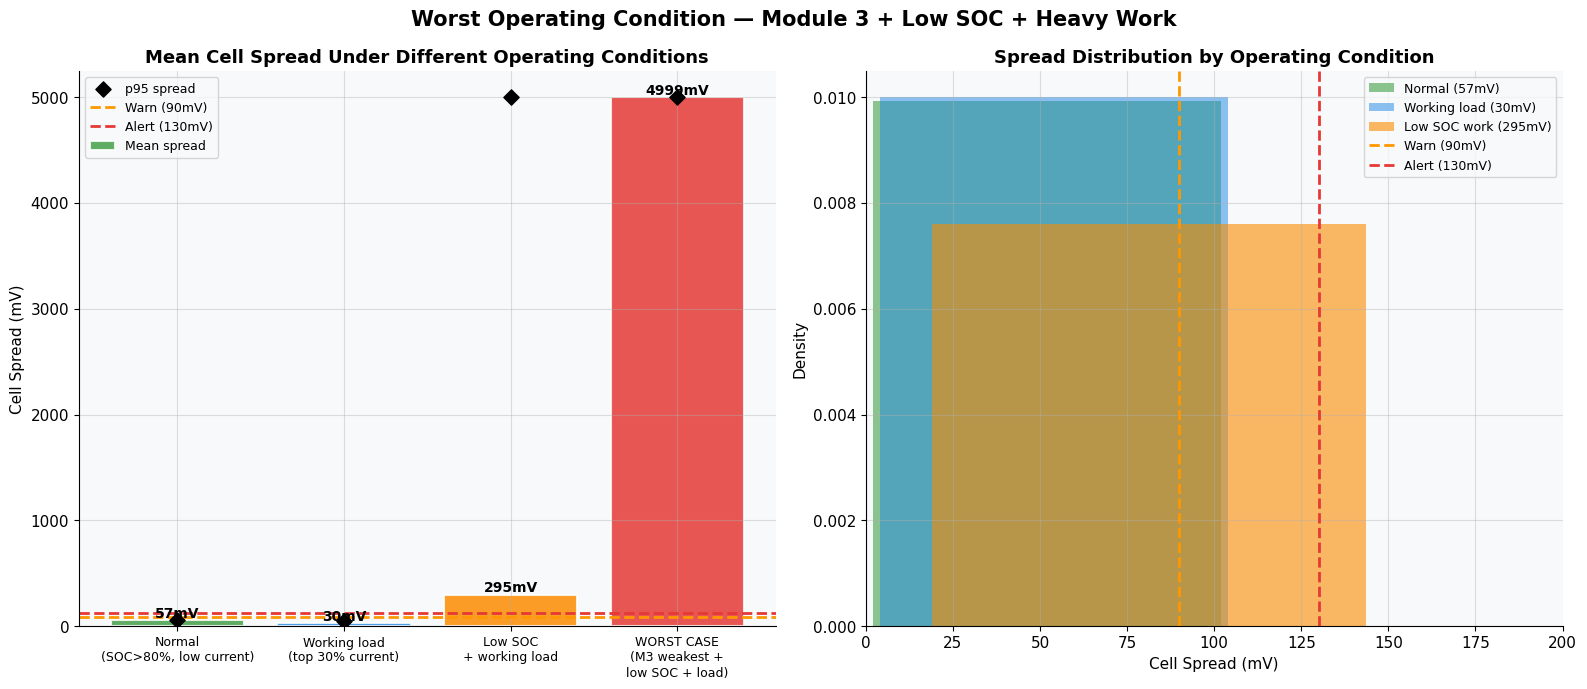

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Worst Operating Condition — Module {hot_mod} + Low SOC + Heavy Work')

conditions = ['Normal\n(SOC>80%, low current)', 'Working load\n(top 30% current)',
              'Low SOC\n+ working load', f'WORST CASE\n(M{hot_mod} weakest +\nlow SOC + load)']
means = [
    normal['cell_spread_v'].mean()*1000 if len(normal) > 0 else 0,
    working['cell_spread_v'].mean()*1000 if len(working) > 0 else 0,
    low_soc_work['cell_spread_v'].mean()*1000 if len(low_soc_work) > 0 else 0,
    m_hot_low_logsoc['cell_spread_v'].mean()*1000 if len(m_hot_low_logsoc) > 0 else 0,
]
p95s = [
    normal['cell_spread_v'].quantile(0.95)*1000 if len(normal) > 0 else 0,
    working['cell_spread_v'].quantile(0.95)*1000 if len(working) > 0 else 0,
    low_soc_work['cell_spread_v'].quantile(0.95)*1000 if len(low_soc_work) > 0 else 0,
    m_hot_low_logsoc['cell_spread_v'].quantile(0.95)*1000 if len(m_hot_low_logsoc) > 0 else 0,
]
ax = axes[0]
bar_colors = ['#43A047', '#1E88E5', '#FB8C00', '#E53935']
x = np.arange(len(conditions))
bars = ax.bar(x, means, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5, label='Mean spread')
ax.scatter(x, p95s, color='black', s=60, zorder=5, marker='D', label='p95 spread')
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=2, label='Warn (90mV)')
ax.axhline(130, color='#E53935', linestyle='--', linewidth=2, label='Alert (130mV)')
ax.set_xticks(x); ax.set_xticklabels(conditions, fontsize=9)
ax.set_ylabel('Cell Spread (mV)'); ax.set_title('Mean Cell Spread Under Different Operating Conditions'); ax.legend(fontsize=9)
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.0f}mV', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[1]
if len(normal) > 0: ax.hist(normal['cell_spread_v']*1000, bins=50, alpha=0.6, color='#43A047', density=True, label=f'Normal ({means[0]:.0f}mV)')
if len(working) > 0: ax.hist(working['cell_spread_v']*1000, bins=50, alpha=0.5, color='#1E88E5', density=True, label=f'Working load ({means[1]:.0f}mV)')
if len(low_soc_work) > 0: ax.hist(low_soc_work['cell_spread_v']*1000, bins=40, alpha=0.6, color='#FB8C00', density=True, label=f'Low SOC work ({means[2]:.0f}mV)')
if len(m_hot_low_logsoc) > 50: ax.hist(m_hot_low_logsoc['cell_spread_v']*1000, bins=30, alpha=0.7, color='#E53935', density=True, label=f'Worst case ({means[3]:.0f}mV)')
ax.axvline(90, color='#FF9800', linestyle='--', linewidth=2, label='Warn (90mV)')
ax.axvline(130, color='#E53935', linestyle='--', linewidth=2, label='Alert (130mV)')
ax.set_title('Spread Distribution by Operating Condition')
ax.set_xlabel('Cell Spread (mV)'); ax.set_ylabel('Density'); ax.set_xlim(0, 200); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/ev02/07_worst_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 — Trip-Level Analysis

**What this does:** Ranks all work sessions by battery stress.
**What to look for:** Are there specific trips that are systematically harder on the pack?

In [18]:
trip_features = df_clean.assign(
    mod_hot=(df_clean['hottest_module'] == hot_mod),
    mod_low=(df_clean['lowest_voltage_module'] == hot_mod),
    low_soc=(df_clean['soc_pct'] <= 20),
    high_load=(df_clean['abs_current_a'] >= work_threshold),
    above_warn=(df_clean['cell_spread_v'] > 0.09),
).groupby('trip_id').agg(
    n=('cell_spread_v', 'size'),
    mean_spread=('cell_spread_v', 'mean'),
    p95_spread=('cell_spread_v', lambda x: x.quantile(0.95)),
    max_spread=('cell_spread_v', 'max'),
    mean_temp_range=('pack_temp_range', 'mean'),
    mean_abs_current=('abs_current_a', 'mean'),
    pct_low_soc=('low_soc', 'mean'),
    pct_high_load=('high_load', 'mean'),
    pct_mod_hot=('mod_hot', 'mean'),
    pct_mod_low=('mod_low', 'mean'),
    pct_above_warn=('above_warn', 'mean'),
)
for col in ['pct_low_soc', 'pct_high_load', 'pct_mod_hot', 'pct_mod_low', 'pct_above_warn']:
    trip_features[col] *= 100

top_trips = trip_features.sort_values('p95_spread', ascending=False).head(15)
print('=== TOP 15 MOST STRESSED TRIPS (by p95 cell spread) ===')
print(top_trips[['n', 'mean_spread', 'p95_spread', 'max_spread', 'mean_abs_current', 'pct_low_soc', 'pct_mod_hot', 'pct_mod_low']].round(3).to_string())
print(f'\nTotal trips analysed: {len(trip_features):,}')
print(f'Trips with mean spread > 90mV: {(trip_features["mean_spread"] > 0.09).sum()}')
print(f'Trips with max spread > 130mV: {(trip_features["max_spread"] > 0.13).sum()}')

=== TOP 15 MOST STRESSED TRIPS (by p95 cell spread) ===
               n  mean_spread  p95_spread  max_spread  mean_abs_current  pct_low_soc  pct_mod_hot  pct_mod_low
trip_id                                                                                                       
EV02_000262  637        2.335       4.999       4.999            40.816       56.201       23.548        7.221
EV02_000277  154        0.063       0.095       0.096           106.980        0.000       41.558        0.000
EV02_000264  252        0.042       0.090       0.091            38.381        0.000        0.000        0.794
EV02_000208   39        0.083       0.088       0.088             0.000        0.000      100.000        0.000
EV02_000226  514        0.053       0.081       0.082            36.824        0.000      100.000        0.195
EV02_000281  489        0.049       0.074       0.078           170.010        0.000        0.000        0.000
EV02_000249    2        0.068       0.068       0.068   

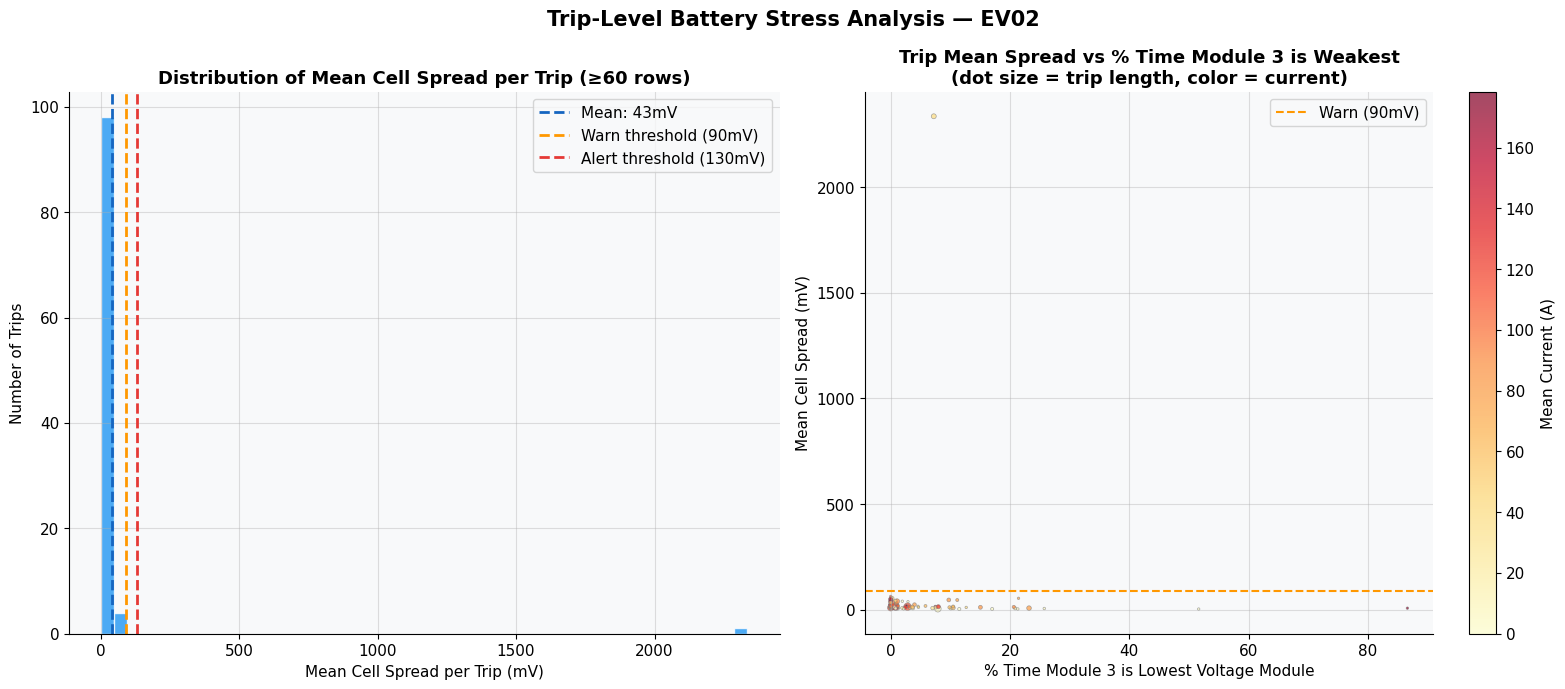

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Trip-Level Battery Stress Analysis — EV02')

ax = axes[0]
trip_means = trip_features[trip_features['n'] >= 60]['mean_spread'] * 1000
ax.hist(trip_means, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(trip_means.mean(), color='#1565C0', linestyle='--', linewidth=2, label=f'Mean: {trip_means.mean():.0f}mV')
ax.axvline(90, color='#FF9800', linestyle='--', linewidth=2, label='Warn threshold (90mV)')
ax.axvline(130, color='#E53935', linestyle='--', linewidth=2, label='Alert threshold (130mV)')
ax.set_title('Distribution of Mean Cell Spread per Trip (≥60 rows)')
ax.set_xlabel('Mean Cell Spread per Trip (mV)'); ax.set_ylabel('Number of Trips'); ax.legend()

ax = axes[1]
plot_trips = trip_features[trip_features['n'] >= 60].copy()
sc = ax.scatter(plot_trips['pct_mod_low'], plot_trips['mean_spread']*1000,
    c=plot_trips['mean_abs_current'], cmap='YlOrRd',
    s=plot_trips['n']/50, alpha=0.7, edgecolors='gray', linewidth=0.5)
plt.colorbar(sc, ax=ax, label='Mean Current (A)')
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=1.5, label='Warn (90mV)')
ax.set_title(f'Trip Mean Spread vs % Time Module {hot_mod} is Weakest\n(dot size = trip length, color = current)')
ax.set_xlabel(f'% Time Module {hot_mod} is Lowest Voltage Module')
ax.set_ylabel('Mean Cell Spread (mV)'); ax.legend()

plt.tight_layout()
plt.savefig('outputs/ev02/08_trip_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — Summary Dashboard

**What this does:** Consolidates all findings into a single executive summary page.

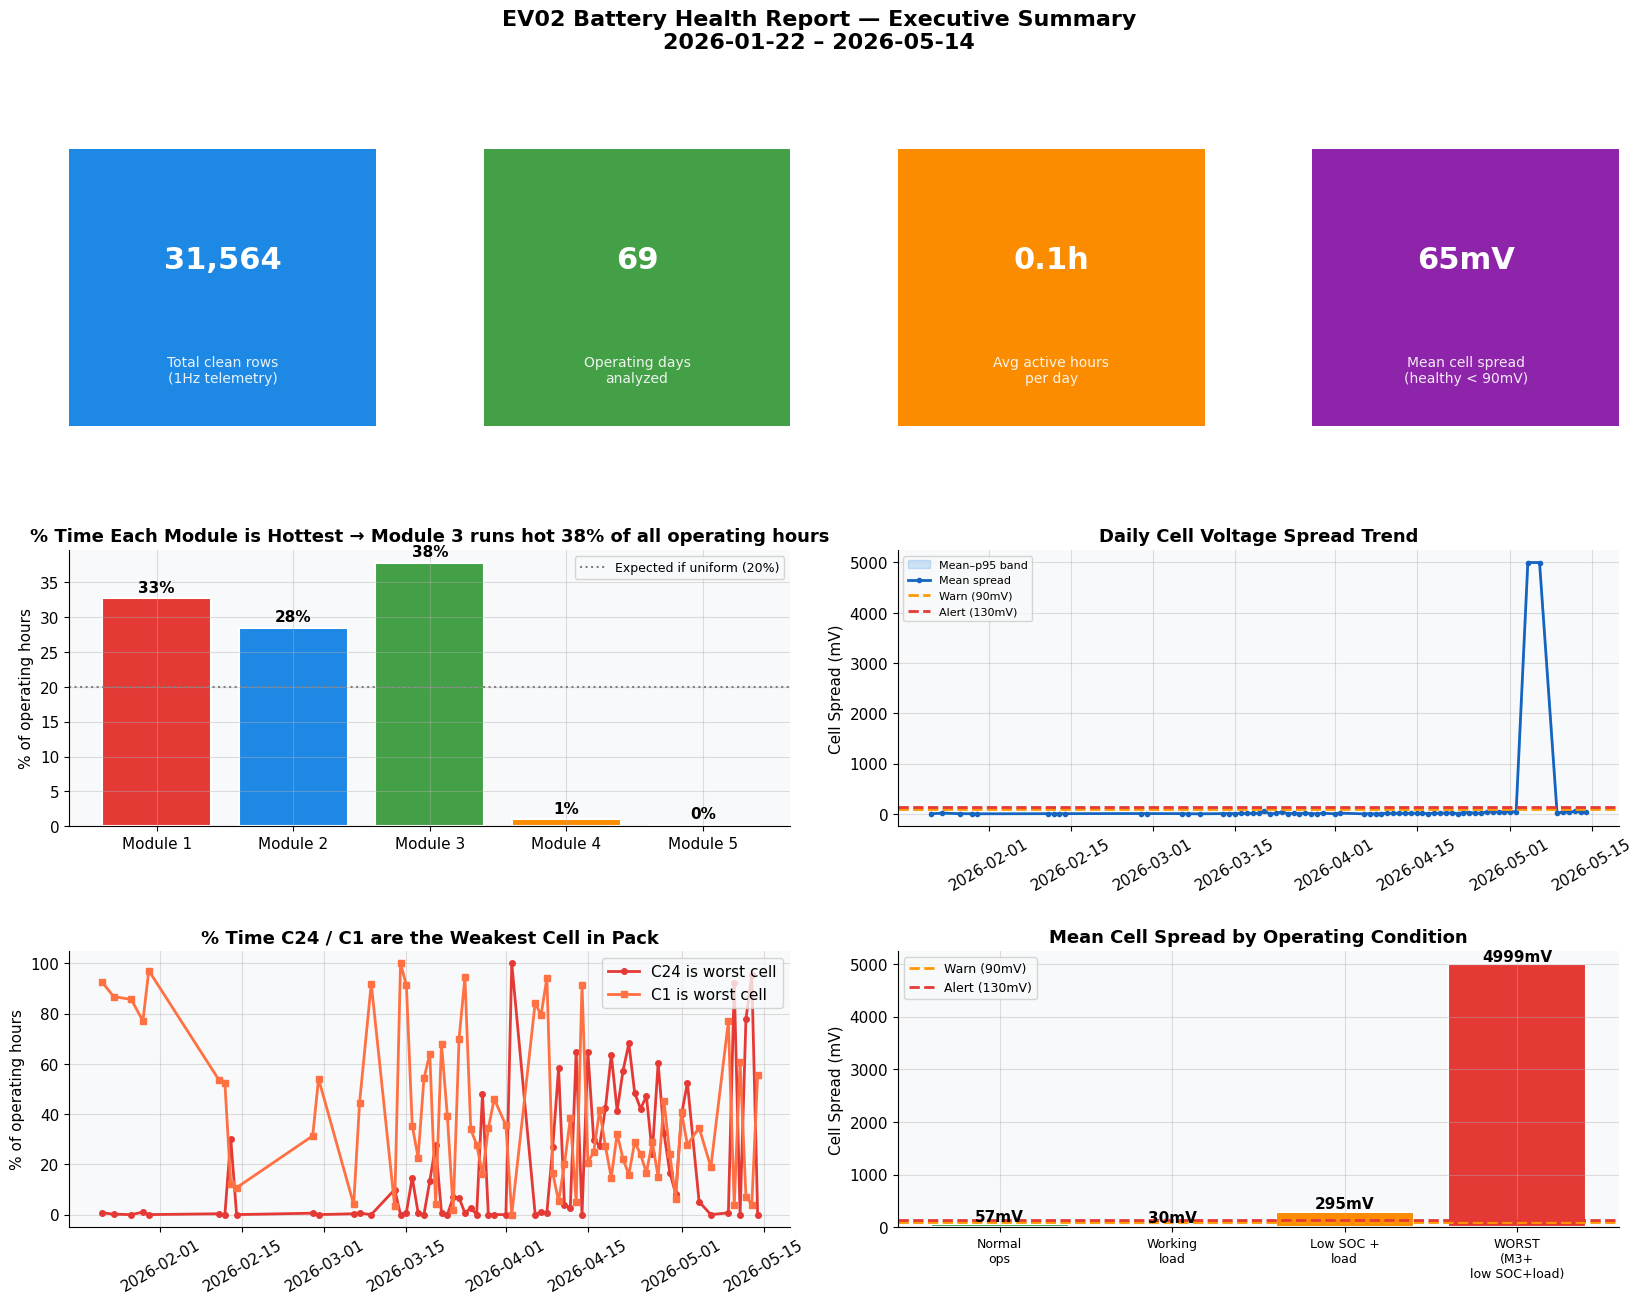

Dashboard saved to outputs/ev02/09_executive_summary.png


In [20]:
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f'EV02 Battery Health Report — Executive Summary\n{df_clean["date"].min()} – {df_clean["date"].max()}',
             fontsize=16, fontweight='bold', y=0.98)

metrics = [
    (f'{len(df_clean):,}', 'Total clean rows\n(1Hz telemetry)'),
    (f'{df_clean["date"].nunique()}', 'Operating days\nanalyzed'),
    (f"{daily['active_hours'].mean():.1f}h", 'Avg active hours\nper day'),
    (f"{df_clean['cell_spread_v'].mean()*1000:.0f}mV", 'Mean cell spread\n(healthy < 90mV)'),
]
metric_colors = ['#1E88E5', '#43A047', '#FB8C00', '#8E24AA']
for idx, (val, label) in enumerate(metrics):
    ax = fig.add_subplot(gs[0, idx])
    ax.set_facecolor(metric_colors[idx])
    ax.text(0.5, 0.6, val, transform=ax.transAxes, ha='center', va='center', fontsize=22, fontweight='bold', color='white')
    ax.text(0.5, 0.2, label, transform=ax.transAxes, ha='center', va='center', fontsize=10, color='white', alpha=0.9)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

ax = fig.add_subplot(gs[1, :2])
hot_pct = [(df_clean['hottest_module'] == i).mean()*100 for i in range(1, 6)]
bars = ax.bar([f'Module {i}' for i in range(1, 6)], hot_pct, color=[MODULE_COLORS[i] for i in range(1, 6)], edgecolor='white', linewidth=1.5)
ax.axhline(20, color='gray', linestyle=':', linewidth=1.5, label='Expected if uniform (20%)')
ax.set_title(f'% Time Each Module is Hottest → Module {hot_mod} runs hot {max(hot_pct):.0f}% of all operating hours')
ax.set_ylabel('% of operating hours'); ax.legend(fontsize=9)
for bar, val in zip(bars, hot_pct):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax = fig.add_subplot(gs[1, 2:])
ax.fill_between(pd.to_datetime(daily_health['date']), daily_health['mean_spread']*1000, daily_health['p95_spread']*1000, alpha=0.2, color='#1E88E5', label='Mean–p95 band')
ax.plot(pd.to_datetime(daily_health['date']), daily_health['mean_spread']*1000, color='#1565C0', linewidth=2, marker='o', markersize=3, label='Mean spread')
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=2, label='Warn (90mV)')
ax.axhline(130, color='#E53935', linestyle='--', linewidth=2, label='Alert (130mV)')
ax.set_title('Daily Cell Voltage Spread Trend'); ax.set_ylabel('Cell Spread (mV)')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

ax = fig.add_subplot(gs[2, :2])
ax.plot(pd.to_datetime(daily_cells['date']), daily_cells['pct_c1_worst']*100, color='#E53935', linewidth=2, marker='o', markersize=4, label=f'{c1_pos} is worst cell')
ax.plot(pd.to_datetime(daily_cells['date']), daily_cells['pct_c2_worst']*100, color='#FF7043', linewidth=2, marker='s', markersize=4, label=f'{c2_pos} is worst cell')
ax.set_title(f'% Time {c1_pos} / {c2_pos} are the Weakest Cell in Pack')
ax.set_ylabel('% of operating hours'); ax.legend(); ax.tick_params(axis='x', rotation=30)

ax = fig.add_subplot(gs[2, 2:])
cond_labels = ['Normal\nops', 'Working\nload', 'Low SOC +\nload', f'WORST\n(M{hot_mod}+\nlow SOC+load)']
bars2 = ax.bar(range(len(cond_labels)), means, color=['#43A047','#1E88E5','#FB8C00','#E53935'], edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(cond_labels))); ax.set_xticklabels(cond_labels, fontsize=9)
ax.axhline(90, color='#FF9800', linestyle='--', linewidth=2, label='Warn (90mV)')
ax.axhline(130, color='#E53935', linestyle='--', linewidth=2, label='Alert (130mV)')
ax.set_title('Mean Cell Spread by Operating Condition'); ax.set_ylabel('Cell Spread (mV)'); ax.legend(fontsize=9)
for bar, val in zip(bars2, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}mV', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.savefig('outputs/ev02/09_executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to outputs/ev02/09_executive_summary.png')

---
## Section 11 — Findings Summary

**Run this cell to print the computed findings derived from EV02 data.**

In [21]:
print('=' * 70)
print('EV02 BATTERY HEALTH DIAGNOSTIC — KEY FINDINGS')
print(f'Electrified Excavator | {df_clean["date"].min()} – {df_clean["date"].max()}')
print('=' * 70)

mean_spread_mv = df_clean['cell_spread_v'].mean() * 1000
p95_spread_mv = df_clean['cell_spread_v'].quantile(0.95) * 1000
pct_above_warn = (df_clean['cell_spread_v'] > 0.09).mean() * 100
pct_above_alert = (df_clean['cell_spread_v'] > 0.13).mean() * 100
hot_mod_pct = (df_clean['hottest_module'] == hot_mod).mean() * 100
c1_pct = df_clean['is_c1_worst'].mean() * 100
c2_pct = df_clean['is_c2_worst'].mean() * 100

print(f"""
OPERATING PROFILE
──────────────────
Total operating days:      {df_clean['date'].nunique()}
Average active hours/day:  {daily['active_hours'].mean():.1f}h
Median SOC (operating):    {df_clean['soc_pct'].median():.0f}%
Total trips:               {df_clean['trip_id'].nunique():,}

PACK HEALTH
────────────
Mean cell spread:          {mean_spread_mv:.1f} mV  (warn: 90mV, alert: 130mV)
p95 cell spread:           {p95_spread_mv:.1f} mV
% time above warn (90mV):  {pct_above_warn:.1f}%
% time above alert (130mV):{pct_above_alert:.1f}%
Mean pack temp range:      {df_clean['pack_temp_range'].mean():.1f}°C

THERMAL DOMINANCE
──────────────────
Module {hot_mod} is hottest: {hot_mod_pct:.1f}% of all operating hours

CELL DEGRADATION
─────────────────
{c1_pos} is worst cell: {c1_pct:.1f}% of operating hours
{c2_pos} is worst cell: {c2_pct:.1f}% of operating hours
Imbalance vs current corr:  {spread_cur_corr:.3f}

WORST OPERATING CONDITION
──────────────────────────
Normal spread:             {means[0]:.0f} mV
Working load spread:       {means[1]:.0f} mV
Low SOC + working load:    {means[2]:.0f} mV
Worst case (M{hot_mod}+low SOC+load): {means[3]:.0f} mV
""")

if mean_spread_mv < 60:
    print('Pack health:    HEALTHY — mean spread well within thresholds')
elif mean_spread_mv < 90:
    print('Pack health:    MONITOR — mean spread approaching warn threshold')
else:
    print('Pack health:    DEGRADED — mean spread above warn threshold')

if pct_above_warn < 5:
    print(f'Warn breaches:  LOW ({pct_above_warn:.1f}% of time above 90mV)')
else:
    print(f'Warn breaches:  ELEVATED ({pct_above_warn:.1f}% of time above 90mV)')

print(f'Module {hot_mod}:       MONITOR — consistently hottest ({hot_mod_pct:.0f}% of time)')
print(f'Cells {c1_pos}/{c2_pos}: WATCH — chronically weakest cell positions')
print('=' * 70)

EV02 BATTERY HEALTH DIAGNOSTIC — KEY FINDINGS
Electrified Excavator | 2026-01-22 – 2026-05-14

OPERATING PROFILE
──────────────────
Total operating days:      69
Average active hours/day:  0.1h
Median SOC (operating):    69%
Total trips:               131

PACK HEALTH
────────────
Mean cell spread:          64.9 mV  (warn: 90mV, alert: 130mV)
p95 cell spread:           50.0 mV
% time above warn (90mV):  1.1%
% time above alert (130mV):0.9%
Mean pack temp range:      19.4°C

THERMAL DOMINANCE
──────────────────
Module 3 is hottest: 37.7% of all operating hours

CELL DEGRADATION
─────────────────
C24 is worst cell: 30.3% of operating hours
C1 is worst cell: 36.3% of operating hours
Imbalance vs current corr:  -0.043

WORST OPERATING CONDITION
──────────────────────────
Normal spread:             57 mV
Working load spread:       30 mV
Low SOC + working load:    295 mV
Worst case (M3+low SOC+load): 4999 mV

Pack health:    MONITOR — mean spread approaching warn threshold
Warn breaches:  LO